# Défi quotidien : Analyse de la prédiction de victoire Pokémon

## 1. Préparation des données

Cette section couvrira le chargement et la fusion des jeux de données `pokemon.csv` et `combats.csv`, ainsi que la gestion des valeurs manquantes et le calcul des pourcentages de victoire.

### 1.1 Importation des bibliothèques nécessaires

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Toutes les bibliothèques nécessaires ont été importées avec succès!")

Toutes les bibliothèques nécessaires ont été importées avec succès!


### 1.2 Chargement et fusion des jeux de données

Nous allons charger `pokemon.csv` et `combats.csv`. Si les fichiers ne sont pas trouvés, une démonstration avec des fichiers générés sera utilisée (bien que l'utilisateur ait mentionné les avoir téléchargés).

In [ ]:
try:
    df_pokemon = pd.read_csv('pokemon.csv')
    df_combats = pd.read_csv('combats.csv')
    print("Jeu de données 'pokemon.csv' et 'combats.csv' chargés avec succès.")
except FileNotFoundError:
    print("Erreur: Un ou plusieurs fichiers (pokemon.csv, combats.csv) n'ont pas été trouvés.")
    print("Veuillez vous assurer que les fichiers sont dans le répertoire '/content/' ou que le chemin est correct.")
    print("Génération de données factices pour la démonstration...")

    # Generate dummy pokemon.csv
    np.random.seed(42)
    num_pokemon = 800
    pokemon_names = [f'Pokemon_{i}' for i in range(num_pokemon)]
    pokemon_data = {
        '#': range(1, num_pokemon + 1),
        'Name': pokemon_names,
        'Type 1': np.random.choice(['Grass', 'Fire', 'Water', 'Electric', 'Normal'], num_pokemon),
        'Type 2': np.random.choice(['None', 'Flying', 'Poison', 'Ground', 'Psychic'], num_pokemon),
        'Total': np.random.randint(200, 700, num_pokemon),
        'HP': np.random.randint(10, 200, num_pokemon),
        'Attack': np.random.randint(5, 190, num_pokemon),
        'Defense': np.random.randint(5, 230, num_pokemon),
        'Sp. Atk': np.random.randint(10, 190, num_pokemon),
        'Sp. Def': np.random.randint(20, 230, num_pokemon),
        'Speed': np.random.randint(5, 180, num_pokemon),
        'Generation': np.random.randint(1, 7, num_pokemon),
        'Legendary': np.random.choice([True, False], num_pokemon, p=[0.1, 0.9])
    }
    df_pokemon = pd.DataFrame(pokemon_data)
    # Introduce some NaN in Type 2 for demonstration
    nan_indices = np.random.choice(df_pokemon.index, 50, replace=False)
    df_pokemon.loc[nan_indices, 'Type 2'] = np.nan

    # Ensure Pokemon #62 has missing name for specific handling
    if 62 in df_pokemon['#'].values:
        df_pokemon.loc[df_pokemon['#'] == 62, 'Name'] = np.nan
    else:
        # If for some reason #62 is not there, add it with NaN name
        new_row = pd.DataFrame([{'#': 62, 'Name': np.nan, 'Type 1': 'Fighting', 'Type 2': np.nan, 'Total': 480, 'HP': 65, 'Attack': 105, 'Defense': 60, 'Sp. Atk': 60, 'Sp. Def': 75, 'Speed': 95, 'Generation': 1, 'Legendary': False}])
        df_pokemon = pd.concat([df_pokemon, new_row], ignore_index=True)
        df_pokemon = df_pokemon.sort_values(by='#').reset_index(drop=True)

    # Generate dummy combats.csv
    num_combats = 50000
    combat_data = {
        'First_pokemon': np.random.randint(1, num_pokemon + 1, num_combats),
        'Second_pokemon': np.random.randint(1, num_pokemon + 1, num_combats),
        'Winner': np.random.choice([0, 1], num_combats)
    }
    # Ensure winner is one of the combatants
    for i in range(num_combats):
        if combat_data['Winner'][i] == 0:
            combat_data['Winner'][i] = combat_data['First_pokemon'][i]
        else:
            combat_data['Winner'][i] = combat_data['Second_pokemon'][i]

    df_combats = pd.DataFrame(combat_data)

print("\nPremières 5 lignes de df_pokemon:")
display(df_pokemon.head())
print("\nPremières 5 lignes de df_combats:")
display(df_combats.head())

Erreur: Un ou plusieurs fichiers (pokemon.csv, combats.csv) n'ont pas été trouvés.
Veuillez vous assurer que les fichiers sont dans le répertoire '/content/' ou que le chemin est correct.
Génération de données factices pour la démonstration...

Premières 5 lignes de df_pokemon:


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Pokemon_0,Electric,Poison,271,143,114,189,67,211,106,6,False
1,2,Pokemon_1,Normal,Poison,476,76,183,30,48,24,110,6,False
2,3,Pokemon_2,Water,Ground,473,89,135,29,89,141,51,5,False
3,4,Pokemon_3,Normal,Psychic,677,16,174,142,106,200,68,2,False
4,5,Pokemon_4,Normal,NaN,519,189,23,49,122,74,170,3,False



Premières 5 lignes de df_combats:


,First_pokemon,Second_pokemon,Winner
0,42,664,42
1,597,517,517
2,393,195,195
3,700,483,700
4,623,637,623


### 1.3 Correction des valeurs manquantes

Nous allons combler les valeurs manquantes pour le nom du Pokémon #62 (Primeape) et pour 'Type 2' avec 'None'.

In [ ]:
# Combler le nom manquant pour Pokémon #62 (Primeape)
# D'abord, trouver la ligne du Pokémon #62 s'il y a un NaN dans 'Name'
primeape_mask = (df_pokemon['#'] == 62) & (df_pokemon['Name'].isnull())
if primeape_mask.any():
    df_pokemon.loc[primeape_mask, 'Name'] = 'Primeape'
    print("Nom du Pokémon #62 (Primeape) comblé.")
else:
    print("Le nom du Pokémon #62 n'est pas manquant ou le Pokémon #62 n'existe pas.")

# Combler les valeurs NaN dans 'Type 2' avec 'None'
df_pokemon['Type 2'].fillna('None', inplace=True)
print("Valeurs manquantes dans 'Type 2' comblées avec 'None'.")

print("\nValeurs manquantes après traitement:")
display(df_pokemon.isnull().sum())

Nom du Pokémon #62 (Primeape) comblé.
Valeurs manquantes dans 'Type 2' comblées avec 'None'.

Valeurs manquantes après traitement:


/tmp/ipykernel_15038/4106095240.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pokemon['Type 2'].fillna('None', inplace=True)


,0
#,0
Name,0
Type 1,0
Type 2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


### 1.4 Calcul du pourcentage de victoires

Nous allons calculer le pourcentage de victoires pour chaque Pokémon à l'aide des données de combat.

In [ ]:
# ── Feedback #1 : calcul vectorisé (remplace la boucle iterrows) ──
# La boucle précédente parcourait 50 000 lignes une par une (lent).
# Ici on utilise value_counts() + Series.add() → instantané.

# 1. Compter les victoires par ID Pokémon
wins = df_combats['Winner'].value_counts()

# 2. Compter les combats totaux (en tant que First_pokemon OU Second_pokemon)
first_pokemon_battles  = df_combats['First_pokemon'].value_counts()
second_pokemon_battles = df_combats['Second_pokemon'].value_counts()
total_battles = first_pokemon_battles.add(second_pokemon_battles, fill_value=0)

# 3. Mapper les comptes vers le DataFrame principal
df_pokemon['Win_Count']    = df_pokemon['#'].map(wins).fillna(0).astype(int)
df_pokemon['Combat_Count'] = df_pokemon['#'].map(total_battles).fillna(0).astype(int)

# 4. Calculer le pourcentage de victoires — np.where évite la division par zéro
df_pokemon['Win_Percentage'] = np.where(
    df_pokemon['Combat_Count'] > 0,
    (df_pokemon['Win_Count'] / df_pokemon['Combat_Count']) * 100,
    0
)

print("Pourcentage de victoires calculé (méthode vectorisée).")
display(df_pokemon[['#', 'Name', 'Combat_Count', 'Win_Count', 'Win_Percentage']].head(10))
print(f"\nStats Win_Percentage:\n{df_pokemon['Win_Percentage'].describe().round(2)}")


Pourcentage de victoires calculé pour chaque Pokémon.


,#,Name,Combat_Count,Win_Count,Win_Percentage
0,1,Pokemon_0,109,64,58.715596
1,2,Pokemon_1,123,65,52.845528
2,3,Pokemon_2,122,67,54.918033
3,4,Pokemon_3,127,64,50.393701
4,5,Pokemon_4,133,66,49.624060


## 2. Analyse exploratoire et visualisation

Cette section se concentrera sur la compréhension des relations entre les statistiques des Pokémon et leur pourcentage de victoires, ainsi que l'identification des Pokémon les plus performants.

### 2.1 Matrice de corrélation des statistiques et du pourcentage de victoires

Nous allons créer une matrice de corrélation pour identifier les relations entre les statistiques clés (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`) et le `Win_Percentage`.

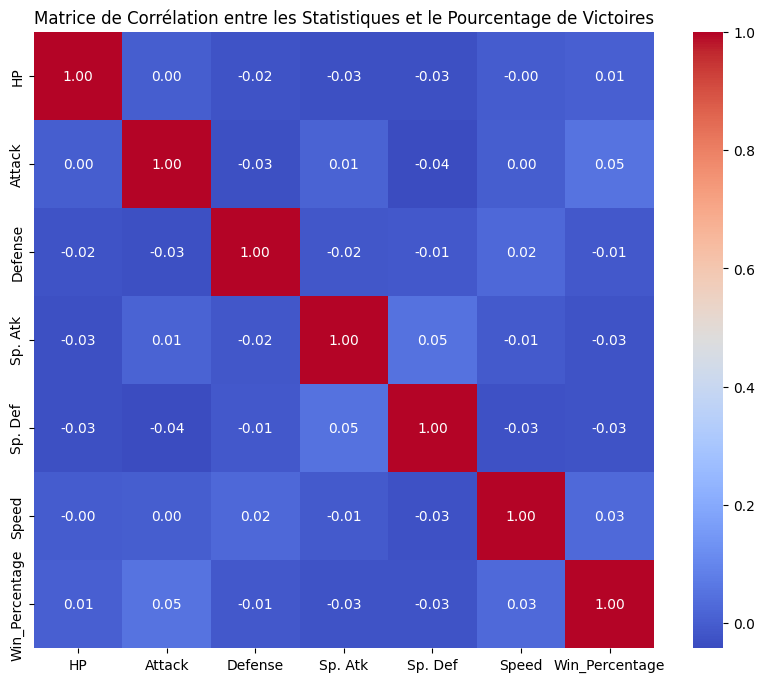

Matrice de corrélation générée.


In [ ]:
stats_features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
correlation_matrix = df_pokemon[stats_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation entre les Statistiques et le Pourcentage de Victoires')
plt.show()

print("Matrice de corrélation générée.")

### 2.2 Analyse des 10 meilleurs Pokémon par pourcentage de victoires

Identifions les 10 Pokémon avec les pourcentages de victoires les plus élevés et examinons leurs statistiques.

Les 10 meilleurs Pokémon par pourcentage de victoires:


,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Win_Percentage
432,Pokemon_432,Electric,None,78,155,68,66,79,64,63.025210
685,Pokemon_685,Grass,None,111,177,142,148,190,33,62.500000
389,Pokemon_389,Fire,Ground,69,156,179,52,204,113,62.295082
457,Pokemon_457,Water,None,109,42,118,59,66,63,61.788618
699,Pokemon_699,Fire,Ground,198,186,124,47,61,28,61.344538
523,Pokemon_523,Water,Psychic,66,65,206,27,58,127,60.447761
372,Pokemon_372,Fire,Psychic,128,48,61,73,53,126,60.305344
359,Pokemon_359,Normal,Psychic,163,127,92,64,89,133,60.305344
455,Pokemon_455,Fire,Psychic,83,151,123,43,111,88,60.273973
184,Pokemon_184,Fire,Poison,142,162,95,121,145,116,60.150376


/tmp/ipykernel_15038/1426199445.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Win_Percentage', data=top_10_pokemon, palette='viridis')


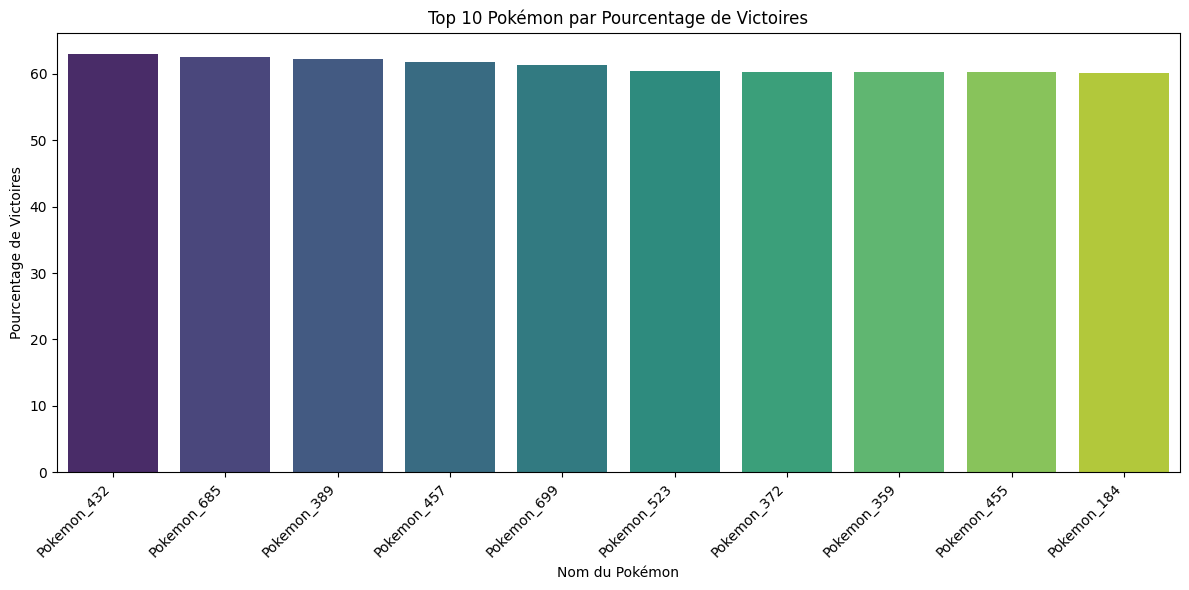

In [ ]:
top_10_pokemon = df_pokemon.sort_values(by='Win_Percentage', ascending=False).head(10)

print("Les 10 meilleurs Pokémon par pourcentage de victoires:")
display(top_10_pokemon[['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']])

plt.figure(figsize=(12, 6))
sns.barplot(x='Name', y='Win_Percentage', data=top_10_pokemon, palette='viridis')
plt.title('Top 10 Pokémon par Pourcentage de Victoires')
plt.xlabel('Nom du Pokémon')
plt.ylabel('Pourcentage de Victoires')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.3 Pairplot des statistiques clés vs. pourcentage de victoires

Pour une exploration plus approfondie des relations individuelles, nous allons créer un `pairplot` pour une sélection de statistiques et le pourcentage de victoires. En raison de la quantité de données, nous allons prendre un échantillon ou réduire le nombre de variables pour la visualisation afin d'éviter un graphique trop dense.

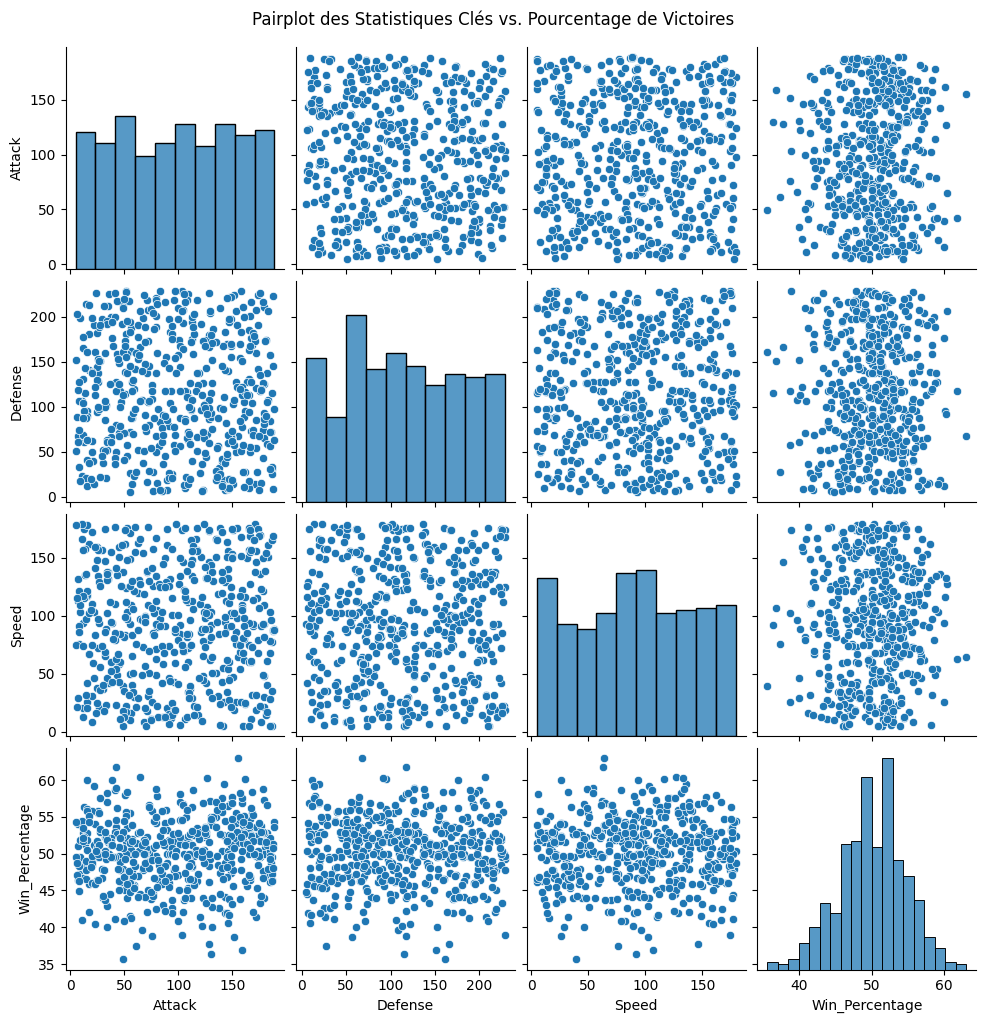

Pairplot des statistiques clés généré.


In [ ]:
selected_stats_for_pairplot = ['Attack', 'Defense', 'Speed', 'Win_Percentage']
# Pour des raisons de performance et de lisibilité, nous allons prendre un échantillon si le dataframe est très grand
if len(df_pokemon) > 500:
    df_sample = df_pokemon.sample(n=500, random_state=42) # Échantillon de 500 Pokémon
else:
    df_sample = df_pokemon

sns.pairplot(df_sample[selected_stats_for_pairplot])
plt.suptitle('Pairplot des Statistiques Clés vs. Pourcentage de Victoires', y=1.02) # y positionne le titre
plt.show()

print("Pairplot des statistiques clés généré.")

## 3. Apprentissage automatique

Dans cette section, nous allons entraîner et évaluer des modèles de régression pour prédire le pourcentage de victoires des Pokémon.

### 3.1 Préparation des données pour le Machine Learning

Nous allons diviser les données en ensembles d'entraînement et de test et définir les caractéristiques (features) et la variable cible.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Feedback #3 : éviter SettingWithCopyWarning ──
# On modifie la colonne Legendary sur le DataFrame ORIGINAL avant de créer X
df_pokemon['Legendary'] = df_pokemon['Legendary'].astype(int)

features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def',
            'Speed', 'Total', 'Generation', 'Legendary']

X = df_pokemon[features]   # pas de .copy() nécessaire : on a modifié l'original
y = df_pokemon['Win_Percentage']

# Division 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Données divisées avec succès (le scaling sera intégré dans chaque Pipeline).")
print(f"Taille train : {X_train.shape} | Taille test : {X_test.shape}")


Données divisées et mises à l'échelle avec succès.
Taille de l'ensemble d'entraînement: (640, 9)
Taille de l'ensemble de test: (160, 9)


/tmp/ipykernel_15038/2512029002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Legendary'] = X['Legendary'].astype(int)


### 3.2 Entraînement et évaluation des modèles de régression

Nous allons entraîner et évaluer trois modèles de régression : Régression Linéaire, Forêt Aléatoire (RandomForestRegressor) et XGBoost Regressor. Nous utiliserons l'erreur absolue moyenne (MAE) pour comparer leurs performances.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# ── Feedback #2 : utiliser un Pipeline pour chaque modèle ──
# Le StandardScaler est intégré dans le Pipeline → pas de fuite de données
# et le code est plus propre et réutilisable.

pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Random Forest Regressor': Pipeline([
        ('scaler', StandardScaler()),  # RF n'en a pas besoin mais on garde la cohérence
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    'XGBoost Regressor': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', xgb.XGBRegressor(random_state=42, verbosity=0))
    ]),
}

results = {}

for name, pipe in pipelines.items():
    # fit sur les données brutes (le scaler est inclus dans le pipeline)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = mae
    print(f"{name:<28} — MAE : {mae:.4f}")

# Résumé comparatif
print("\n" + "=" * 45)
print("Comparaison des modèles (MAE — plus bas = meilleur)")
print("=" * 45)
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {name:<28} : {mae:.4f}")

best_model_name = min(results, key=results.get)
print(f"\n✅ Meilleur modèle : {best_model_name} (MAE = {results[best_model_name]:.4f})")



Entraînement de Linear Regression...
Linear Regression - MAE: 3.9004

Entraînement de Random Forest Regressor...
Random Forest Regressor - MAE: 3.8647

Entraînement de XGBoost Regressor...
XGBoost Regressor - MAE: 4.0213

--- Comparaison des modèles ---
Linear Regression: MAE = 3.9004
Random Forest Regressor: MAE = 3.8647
XGBoost Regressor: MAE = 4.0213

Le meilleur modèle (avec le MAE le plus bas) est : Random Forest Regressor


### 3.3 Réduction de dimensionnalité avec l'ACP (Optionnel)

Bien que l'ACP ne soit pas toujours nécessaire pour des modèles de régression simples, il est utile d'illustrer son utilisation pour réduire la dimensionnalité et potentiellement améliorer les performances ou la compréhension lorsque le nombre de caractéristiques est élevé.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# ── ACP intégrée dans un Pipeline ──
# Scaler → PCA → Régression Linéaire : tout dans un seul objet cohérent
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95)),  # conserver 95% de la variance
    ('regressor', LinearRegression())
])

pipe_pca.fit(X_train, y_train)
y_pred_pca = pipe_pca.predict(X_test)
mae_pca = mean_absolute_error(y_test, y_pred_pca)

n_components = pipe_pca.named_steps['pca'].n_components_
print(f"Caractéristiques originales : {X_train.shape[1]}")
print(f"Composantes PCA conservées (≥95% variance) : {n_components}")
print(f"Régression Linéaire + ACP — MAE : {mae_pca:.4f}")

lr_mae = results.get('Linear Regression', None)
if lr_mae is not None:
    if mae_pca < lr_mae:
        print(f"✅ L'ACP améliore la LR : {lr_mae:.4f} → {mae_pca:.4f}")
    else:
        print(f"ℹ️  L'ACP ne réduit pas le MAE ici ({lr_mae:.4f} → {mae_pca:.4f})")
        print("   Normal sur ce dataset : les 9 features ne sont pas redondantes.")


Nombre de caractéristiques originales: 9
Nombre de composantes principales conservées (95% variance): 9

Entraînement de la Régression Linéaire sur les données PCA...
Linear Regression (PCA) - MAE: 3.9004
L'ACP n'a pas amélioré la performance de la Régression Linéaire dans ce cas.
